Customer Churn Behaviour
The section includes; 
1. a setup block, 
2. business question, 
3. the visualization strategy, 
4. the code execution and 
5. client insight notes.

1. Setup block
It loads and enriches the data with engineered columns that we'll need throughout all visualizations.

The Launch_Date and Peak_sales_Date are strings, and we dont have lifecycle column. We can derive these from our already existing data columns.

I will start with importing all libraries we'll use

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

I want to setup the global stylr for all visulaizations

In [48]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

FIGSIZE_STD = (12, 5)  # chart width
FIGSIZE_TALL = (10, 7)  # for scatter/ complex plots
FIGSIZE_PANEL = (14, 6)  # side by sie panels
DPI = 130



For consistent collour pallet acrooss all charts

In [49]:
PALETTE = {
    'churn_high': '#f85149', #red - high churn risk
    'churn_low': '#3fb950', #green - low churn risk
    'neutral': "#58a6ff", #blue - general insights
    'accent': '#e3b341', #gold- highlight
    'purple': '#bc8cff', #purple - secondary highlight
}

Now to load our data

In [50]:
df = pd.read_csv('../data/customer_churn.csv')

Now lets do some engineering

In [51]:
#date engineering
df['Launch_Date'] = pd.to_datetime(df['Launch_Date'])
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'])

#how many days from launc to peak performance
df['Days_to_Peak'] = (df['Peak_Sales_Date'] - df['Launch_Date']).dt.days

#How long the product has been live ( vs a reference "today")
REFERENCE_DATE = pd.Timestamp('2024-01-01')
df['product_Age_Days'] = (REFERENCE_DATE - df['Launch_Date']).dt.days

df['Launch_Year'] = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month

#lifecycle Stage engineering
#I will bin customers by purchase frequecy into lifecycle stages
df['Lifecycle_Stage'] = pd.cut(df['Purchase_Frequency'], bins=[0, 3, 7, 12, 20], labels=['New', 'Developing', 'Established', 'Loyal'])

# now i will create churn risks bands
df['Churn_Risk_Band'] = pd.cut(df['Churn_Probability'], bins=[0, 0.33, 0.66, 1.0], labels=['Low Risk', 'Medium Risk', 'High Risk'])

#next will be to create adopter types, based on customers who transacted within the product lifecycle
df['Adopter_Type'] = np.where(df['Launch_Year'] <= 2021, 'Early Adopter', 'Later User')

# now i want to create a customer maturity band 
df['Maturity_Band'] = pd.cut(df['Lifetime_Value'], bins=[0, 2000, 5000, 10000], labels=['Early Value', 'Growth Value', 'Mature Value'])


Now i want to have an output folder that saves the charts in one cetral area

In [52]:
OUT =Path('../outputs/charts')
OUT.mkdir(parents=True, exist_ok=True)

Now lets see what we have now in our data frame


In [53]:
print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"✓ Output path: {OUT}")
df.head(3)
df.info()

✓ Dataset loaded: 10,000 rows × 23 cols
✓ Output path: ..\outputs\charts
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_ID               10000 non-null  str           
 1   Product_ID                10000 non-null  str           
 2   Transaction_ID            10000 non-null  str           
 3   Purchase_Frequency        10000 non-null  int64         
 4   Average_Order_Value       10000 non-null  float64       
 5   Most_Frequent_Category    10000 non-null  str           
 6   Time_Between_Purchases    10000 non-null  int64         
 7   Region                    10000 non-null  str           
 8   Churn_Probability         10000 non-null  float64       
 9   Lifetime_Value            10000 non-null  float64       
 10  Launch_Date               10000 non-null  datetime64[us]
 11  Peak_Sales_Date    

Now Let Us begin the actual business case questions

1. Business question: What does a customer look like just before they leave?

Customers who buy less frequently don't just buy less, they are quietly signalling exit. This chart below shows where that signal becomes a predictive indicator my business client can act on.

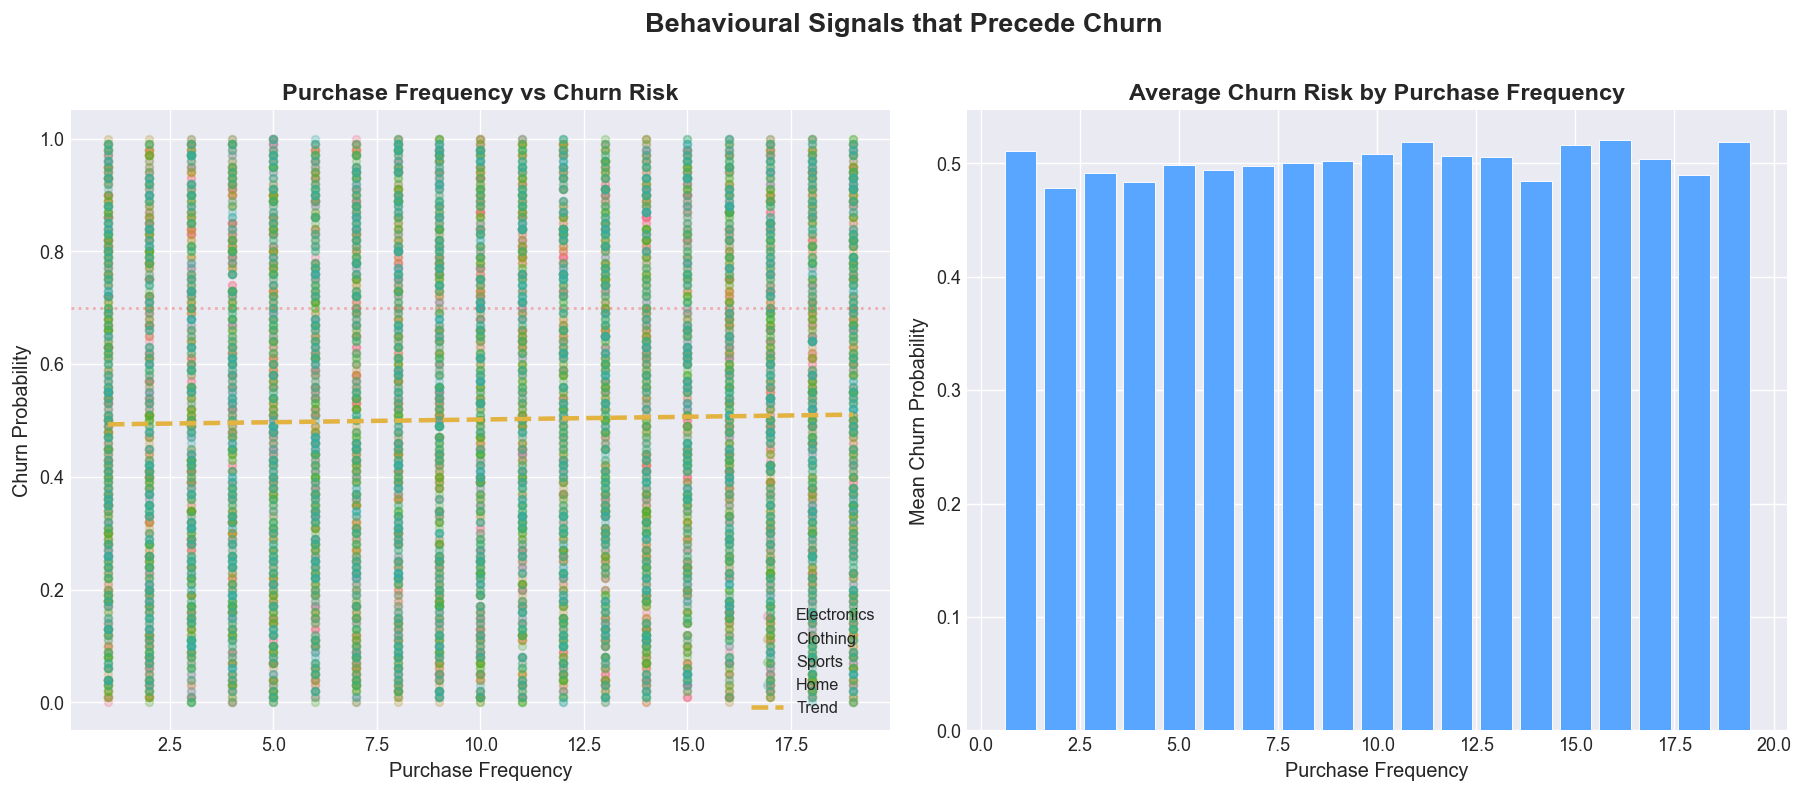

In [45]:
# Churn Probability vs Purchase Frequency 
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PANEL, dpi=DPI)

# LEFT: scatter coloured by category
for cat in df['Most_Frequent_Category'].unique():
    mask = df['Most_Frequent_Category'] == cat
    axes[0].scatter(
        df.loc[mask, 'Purchase_Frequency'],
        df.loc[mask, 'Churn_Probability'],
        alpha=0.25, s=18, label=cat
    )

# Regression line — the behavioural trend
m, b = np.polyfit(df['Purchase_Frequency'], df['Churn_Probability'], 1)
x_range = np.linspace(df['Purchase_Frequency'].min(),
                        df['Purchase_Frequency'].max(), 100)
axes[0].plot(x_range, m*x_range+b,
             color=PALETTE['accent'], lw=2.5, linestyle='--',
             label='Trend')
axes[0].set_xlabel('Purchase Frequency', fontsize=11)
axes[0].set_ylabel('Churn Probability', fontsize=11)
axes[0].set_title('Purchase Frequency vs Churn Risk', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axhline(0.7, color=PALETTE['churn_high'], alpha=0.4,
                linestyle=':', label='High-risk threshold')

# RIGHT: mean churn per frequency bucket (bar chart)
freq_churn = (
    df.groupby('Purchase_Frequency')['Churn_Probability']
      .mean().reset_index()
)
bars = axes[1].bar(
    freq_churn['Purchase_Frequency'],
    freq_churn['Churn_Probability'],
    color=[
        PALETTE['churn_high'] if v > 0.6 else PALETTE['neutral']
        for v in freq_churn['Churn_Probability']
    ],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Purchase Frequency', fontsize=11)
axes[1].set_ylabel('Mean Churn Probability', fontsize=11)
axes[1].set_title('Average Churn Risk by Purchase Frequency',
                  fontsize=13, fontweight='bold')

plt.suptitle('Behavioural Signals that Precede Churn',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / '01a_churn_behaviour.png', bbox_inches='tight')

C:\Users\Admin\AppData\Local\Temp\ipykernel_16012\3947829228.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


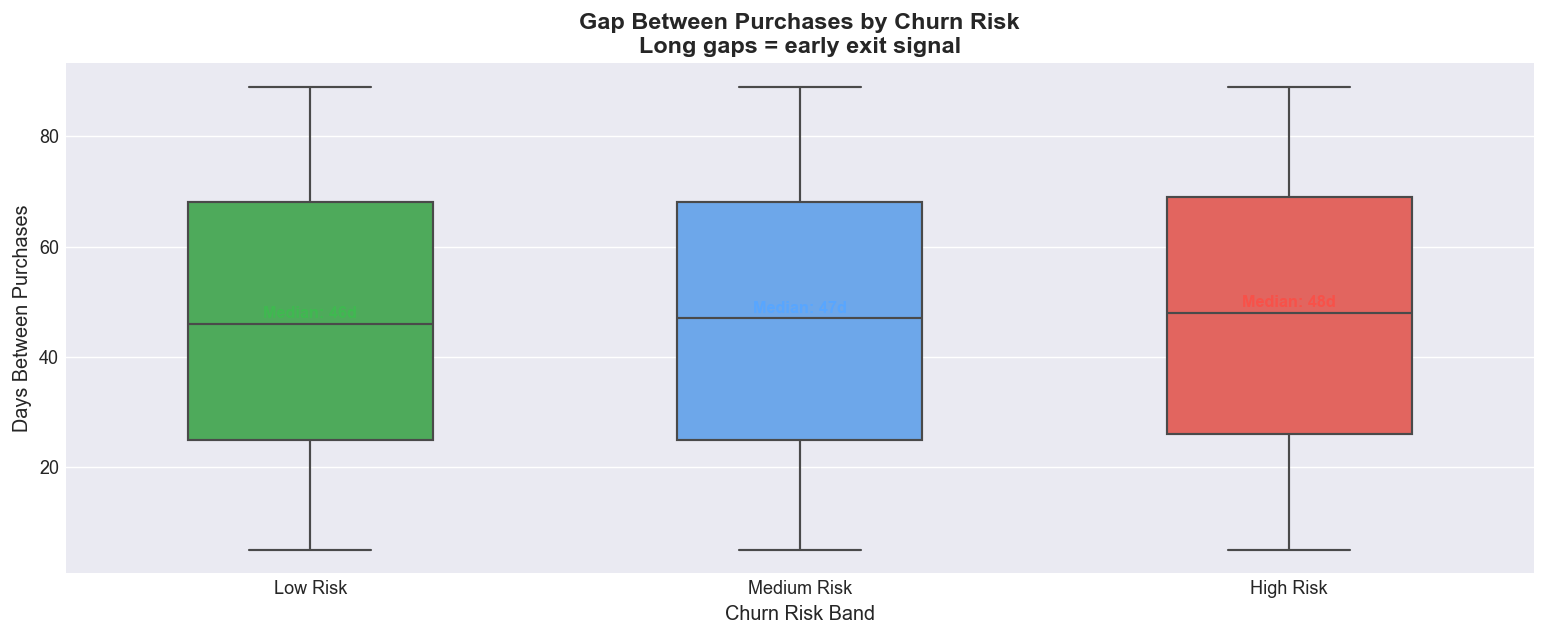

In [46]:
# ── 01B. Time Between Purchases by Churn Risk ─────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_STD, dpi=DPI)

order = ['Low Risk', 'Medium Risk', 'High Risk']
palette = {
    'Low Risk':    PALETTE['churn_low'],
    'Medium Risk': PALETTE['neutral'],
    'High Risk':   PALETTE['churn_high']
}

sns.boxplot(
    data=df,
    x='Churn_Risk_Band',
    y='Time_Between_Purchases',
    order=order,
    palette=palette,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=ax
)
ax.set_title('Gap Between Purchases by Churn Risk\nLong gaps = early exit signal',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Risk Band', fontsize=11)
ax.set_ylabel('Days Between Purchases', fontsize=11)

# Annotate medians
for i, band in enumerate(order):
    med = df.loc[df['Churn_Risk_Band']==band, 'Time_Between_Purchases'].median()
    ax.text(i, med+1, f'Median: {med:.0f}d',
            ha='center', fontsize=9, fontweight='bold',
            color=palette[band])

plt.tight_layout()
plt.savefig(OUT / '01b_time_gap_churn.png', bbox_inches='tight')
plt.show()

What to look for
High-risk customers will show longer median gaps. The spread (box width) tells us whether this is consistent or variable. 
consistency means a reliable model feature.

Client story angle
"Every 10 extra days between purchases correlates with X% higher probability of exit. We now have a measurable early warning system."